# Project: Teaching an LLM to Reason

In this project, you will teach an LLM to use step-by-step reasoning to answer the question: "How many X's are there in the word Y?"

Counting letters in a word is a surprisingly complex task for an LLM. Just as human beings would not be able to answer such a question for longer words without breaking down the word into its individual letters and then counting them, LLMs cannot be similarly expected to be able to respond without using smaller reasoning steps.

For example, to count the number of o's in the word room, one could use the following reasoning:

```
Question: How many of the letter "o" are there in the word "room"
Answer: 2
Response:

<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>
```

In this project we will use the reinforcement learning method GRPO (Group Relative Policy Optimization, of DeepSeek fame) to take a large language model that has been fine-tuned for following instructions and teach it how to break a word down into its letters and then count the requested letter.

We will complete the following steps:

* Set up the notebook
* Create a letter-counting dataset
* Create the reward functions
* Train the model
* View the results

NOTE: This notebook will have you focus on several important aspects of training a GPRO model using LoRA:

1. Configuring LoRA adapters for parameter-efficient fine tuning
2. Selecting reward functions that help the model efficiently find its way to the correct answer (also called reward shaping)
3. Finding hyperparameters that help the model increase the rewards earned more quickly and reliably
4. Learning how to start with smaller experiments and to work your way up to longer experiments.

## Set up the notebook

We'll install dependencies needed for the project, namely `unsloth` and `vllm`, which are useful for fine-tuning LLMs with even just 15GB of VRAM.

In [ ]:
# Load ipython-autotime to see how long each cell take to run
# No changes needed in this cell

!pip install -q ipython-autotime
%load_ext autotime

In [2]:
# Verify we have enough GPU memory to run this project (at least 15360MiB)
# No changes needed in this cell
!nvidia-smi

Fri May 15 15:34:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.57                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 Ti     On  |   00000000:08:00.0  On |                  N/A |
|  0%   51C    P8             20W /  165W |    2988MiB /  16380MiB |     14%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Note: I have written scripts in the src folder to be backend-agnostic, so you can run them with either the unsloth or transformers backend.
# I did not have enough GPU memory to run the unsloth backend with vLLM for training, so I used the transformers backend for training.
# I did however use unsloth for inference, since it is much faster and I have enough GPU memory to run it with vLLM for inference.
print(f"Note: I have written scripts in the src folder to be backend-agnostic, so you can run them with either the unsloth or transformers backend.")
import unsloth
from unsloth import FastLanguageModel
print(f"Unsloth version: {unsloth.__version__}")

import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd() / "src"))

import torch
from model_setup import load_base_model
from config import LORA_RANK   # still used by the explanatory print below

model, tokenizer = load_base_model()

print(f"""
The reason for using LoRA rank as {LORA_RANK} is twofold. 
First is the constraint of my GPU memory. Second is a performance sweet spot. 
Higher ranks can introduce overfitting. 
Lower ranks may not capture enough of the fine-tuning signal. 
Rank {LORA_RANK} strikes a good balance, providing sufficient capacity for learning while keeping memory usage manageable.
      """)

Note: I have written scripts in the src folder to be backend-agnostic, so you can run them with either the unsloth or transformers backend.
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/joran/udacity-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 05-15 15:34:48 [__init__.py:216] Automatically detected platform cuda.
WARNING 05-15 15:34:49 [interface.py:391] Using 'pin_memory=False' as WSL is detected. This may slow down the performance.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth version: 2026.4.6
1 1
INFO 05-15 15:34:56 [vllm_utils.py:724] Unsloth: Patching vLLM v1 graph capture
INFO 05-15 15:34:56 [vllm_utils.py:753] Unsloth: Patching vLLM v0 graph capture
==((====))==  Unsloth 2026.4.6: Fast Qwen2 patching. Transformers: 4.57.6. vLLM: 0.10.2.
   \\   /|    NVIDIA GeForce RTX 4060 Ti. Num GPUs = 1. Max memory: 15.996 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM loading unsloth/qwen2.5-3b-instruct-unsloth-b

`torch_dtype` is deprecated! Use `dtype` instead!


INFO 05-15 15:35:10 [__init__.py:1815] Using max model len 384
WARNING 05-15 15:35:10 [_ipex_ops.py:16] Import error msg: No module named 'intel_extension_for_pytorch'


...

INFO 05-15 15:35:19 [gpu_model_runner.py:2392] Model loading took 2.4503 GiB and 2.854398 seconds
INFO 05-15 15:35:23 [gpu_worker.py:298] Available KV cache memory: 4.55 GiB
INFO 05-15 15:35:23 [kv_cache_utils.py:864] GPU KV cache size: 132,544 tokens
INFO 05-15 15:35:23 [kv_cache_utils.py:868] Maximum concurrency for 384 tokens per request: 345.17x
INFO 05-15 15:35:23 [gpu_worker.py:391] Free memory on device (14.85/16.0 GiB) on startup. Desired GPU memory utilization is (0.4640862053176226, 7.42 GiB). Actual usage is 2.45 GiB for weight, 0.41 GiB for peak activation, 0.02 GiB for non-torch memory, and 0.0 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=4729165824` to fit into requested memory, or `--kv-cache-memory=12702013440` to fully utilize gpu memory. Current kv cache memory in use is 4886452224 bytes.
INFO 05-15 15:35:23 [core.py:218] init engine (profile, create kv cache, warmup model) took 4.49 seconds
INFO 05-15 15:35:25 [llm.py:295] S

Some weights of Qwen2ForCausalLM were not initialized from the model checkpoint at unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit and are newly initialized: ['lm_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Performing substitution for additional_keys=set()
Unsloth: Just some info: will skip parsing ['q_norm', 'layer_norm1', 'norm1', 'post_feedforward_layernorm', 'layer_norm2', 'norm', 'pre_feedforward_layernorm', 'ffn_norm', 'post_attention_layernorm', 'attention_norm', 'norm2', 'cross_attn_input_layernorm', 'k_norm', 'cross_attn_post_attention_layernorm', 'post_layernorm', 'input_layernorm']
unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.6 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.



      The reason for using LoRA rank as 64 is twofold. 
      First is the constraint of my GPU memory. Second is a performance sweet spot. 
      Higher ranks can introduce overfitting. 
      Lower ranks may not capture enough of the fine-tuning signal. 
      Rank 64 strikes a good balance, providing sufficient capacity for learning while keeping memory usage manageable.
      


## Try Prompt Engineering to Count Letters

Let's work on the system prompt a little to see if we can get the model to count the number of the letter `g` in `engage`.


Here you must:
* Write clear instructions
* Break the problem down into steps (Chain-of-Thought prompting)
* Provide at least one example for the model to follow (Few-shot prompting)

In [4]:
# First, let's see what happens when we have a blank system prompt
# No changes needed in this cell
SYSTEM_PROMPT = """"""
USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

from model_setup import generate

output = generate(model, tokenizer, text_for_completion, max_tokens=2048, temperature=0.8, top_p=0.95)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

WARNING 05-15 15:36:50 [cudagraph_dispatcher.py:102] cudagraph dispatching keys are not initialized. No cudagraph will be used.


Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.10s/it, est. speed input: 13.79 toks/s, output: 7.13 toks/s]

=== TEXT FOR COMPLETION ===
<|im_start|>system
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
In the word "engage", there is only one letter "g".


Without any prompting the model will generate an output such as this:

```
=== GENERATED OUTPUT ===
There is one letter "g" in the word "engage".
```

Now let's work on the system prompt to help the model break this problem down into steps, which might help it get the right answer (2 `g`'s in `engage`)

In [5]:
from config import SYSTEM_PROMPT_COT as SYSTEM_PROMPT
USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

output = generate(model, tokenizer, text_for_completion, max_tokens=2048, temperature=0.8, top_p=0.95)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

Processed prompts: 100%|██████████| 1/1 [00:17<00:00, 17.14s/it, est. speed input: 14.12 toks/s, output: 6.77 toks/s]

=== TEXT FOR COMPLETION ===
<|im_start|>system

You count the occurrences of a letter in a word by spelling the word out letter-by-letter and maintaining a running total.

Respond in exactly this format:
<reasoning>
Counting the number of [letter]'s in the word [word]
1. [first letter of word] - [running total] so far
2. [second letter of word] - [running total] so far
...

The letter "[letter]" appears [final total] times in the word "[word]".
</reasoning>
<answer>
[final total]
</answer>

Example:
Question: How many of the letter "o" are there in the word "room"
<reasoning>
Counting the number of o's in the word room
1. r - 0 so far
2. o - 1 so far
3. o - 2 so far
4. m - 2 so far
The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
<reasoning>
Counting the number of g's in the word engage
1. a - 0 so far
2. n -

Did your new prompt get the right answer? Did the model follow all of your instructions?

Maybe yes, maybe no. Either way, we'll want the model to reliably complete this challenge. So let's use GRPO to help it!

## Create a letter-counting dataset

To train a model, we'll first need to create a dataset. We'll use the HuggingFace `datasets` package.

In [6]:
# Create a list of words of different lengths
# No changes are needed in this cell.

ALL_WORDS = [
    "idea",
    "glow",
    "rust",
    "maze",
    "echo",
    "wisp",
    "veto",
    "lush",
    "gaze",
    "knit",
    "fume",
    "plow",
    "void",
    "oath",
    "grim",
    "crisp",
    "lunar",
    "fable",
    "quest",
    "verge",
    "brawn",
    "elude",
    "aisle",
    "ember",
    "crave",
    "ivory",
    "mirth",
    "knack",
    "wryly",
    "onset",
    "mosaic",
    "velvet",
    "sphinx",
    "radius",
    "summit",
    "banner",
    "cipher",
    "glisten",
    "mantle",
    "scarab",
    "expose",
    "fathom",
    "tavern",
    "fusion",
    "relish",
    "lantern",
    "enchant",
    "torrent",
    "capture",
    "orchard",
    "eclipse",
    "frescos",
    "triumph",
    "absolve",
    "gossipy",
    "prelude",
    "whistle",
    "resolve",
    "zealous",
    "mirage",
    "aperture",
    "sapphire",
]

print(len(ALL_WORDS))

ALL_WORDS[:10]

62


['idea',
 'glow',
 'rust',
 'maze',
 'echo',
 'wisp',
 'veto',
 'lush',
 'gaze',
 'knit']

In [7]:
# Create the dataset as a Hugging Face Dataset using Dataset.from_generator
# No changes needed in this cell

from datasets import Dataset
import random


# Go through the letters from the words (as well as letters not in the words),
# and create a labelled dataset with all the different combinations.
# For example for the word gaze:
# 1. How many i's are in idea? <-- count should be 1
# 2. How many d's are in idea? <-- count should be 1
# 3. How many e's are in idea? <-- count should be 1
# 4. How many a's are in idea? <-- count should be 1
# 5. How many b's are in idea? <-- a letter not in word (count should be zero)
def generate_records():
    for word in ALL_WORDS:
        for letter in sorted(set(word)):
            yield {"words": word, "letters": letter, "counts": word.count(letter)}

        # pick random letters not in the word
        num_letters_not_in_word_left = int(len(word) // 7 + 1)

        random.seed(hash(word))

        all_letters = list("abcdefghijklmnopqrstuvwxyz")

        random.shuffle(all_letters)
        for letter in all_letters:
            if letter not in word:
                yield {"words": word, "letters": letter, "counts": 0}
                num_letters_not_in_word_left -= 1
            if num_letters_not_in_word_left == 0:
                break


from dataset import build_dataset
ds = build_dataset()  # uses SYSTEM_PROMPT_FORMAT by default
print("I replaced the original dataset generation code with a call to the function I used to generate the dataset. This allowed me to fire off multiple runs during the night so I get feedback in the morning.")

# Show the first item
ds[0]

I replaced the original dataset generation code with a call to the function I used to generate the dataset. This allowed me to fire off multiple runs during the night so I get feedback in the morning.


{'words': 'idea',
 'letters': 'a',
 'counts': 1,
 'prompt': [{'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n",
   'role': 'system'},
  {'content': 'How many of the letter "a" are there in the word "idea"',
   'role': 'user'}]}

In [8]:
# Add the entire prompt (system + user) and the answer to the dataset
# We'll use a prompt that spells out the word letter-by-letter
# No changes needed in this cell

import re
from datasets import load_dataset, Dataset

# Simple CoT prompt (zero-shot)
SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>
"""

ds = ds.map(
    lambda x: {  # type: ignore
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": 'How many of the letter "{}" are there in the word "{}"'.format(
                    x["letters"], x["words"]
                ),
            },
        ],
    }
)

ds[0]

{'words': 'idea',
 'letters': 'a',
 'counts': 1,
 'prompt': [{'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n",
   'role': 'system'},
  {'content': 'How many of the letter "a" are there in the word "idea"',
   'role': 'user'}]}

In [9]:
# Let's see how well the model runs out-of-the-box
# No changes needed in this cell

text = tokenizer.apply_chat_template(
    ds[0]["prompt"], tokenize=False, add_generation_prompt=True
)

output = generate(model, tokenizer, text_for_completion, max_tokens=1024, temperature=0.8, top_p=0.95)

print(output)

Processed prompts: 100%|██████████| 1/1 [00:11<00:00, 11.63s/it, est. speed input: 20.80 toks/s, output: 8.42 toks/s]

<reasoning>
Counting the number of g's in the word engage
1. e - 0 so far
2. n - 0 so far
3. g - 1 so far
4. a - 1 so far
5. n - 2 so far
6. g - 3 so far
The letter "g" appears 3 times in the word "engage".
</reasoning>
<answer>
3
</answer>


## Create Reward Functions

One goal of creating reward functions is to guide the model toward behaviors that help it reach its goal (counting the occurrences of a letter within a word) more easily. Since there is more than one way to carry out any step-by-step task (e.g. whether or not you use bullet points to separate your steps), there's a bit of judgement involved in choosing what behaviors to reward, i.e. how do we provide partial credit or "shape" our rewards?

In this case we will encourage the model to (whether or not this structure is best):
* use numbers for bullet points when spelling out the word
* to spell the word correctly
* to count the requested letter correctly
* to use the requested reasoning format
* to get the final answer correct.


### Numbering reward function

In [10]:
# Let's work on a function that the numbering in the bullet points is correct
# When using GRPO, we lean on reward functions that are relatively easy to
# compute, thus removing the need to have a second large model just for
# evaluation.
# In this case, we'll use regular expressions quite a bit.

print(f"""
      Like before, I am using the functions I wrote in the rewards.py file to compute the reward for the model's output. 
      This allowed me to test and iterate on the reward function more easily.
      You can see the reward function I wrote in rewards.py, and the tests I wrote to verify it works as expected.
      """)

from rewards import (
    extract_letter_numbering,
    numbering_reward_func,
    assert_numbering_reward,
)
assert_numbering_reward()


      Like before, I am using the functions I wrote in the rewards.py file to compute the reward for the model's output. 
      This allowed me to test and iterate on the reward function more easily.
      You can see the reward function I wrote in rewards.py, and the tests I wrote to verify it works as expected.
      
PASS numbering_reward_func [-0.5, 0.25]


### Spelling reward function

In [11]:
from rewards import (
    extract_spelling,
    spelling_reward_func,
    assert_spelling_reward,
)
assert_spelling_reward()

PASS spelling_reward_func [-1.5, 2.0]


### Counting reward function

In [12]:
from rewards import (
    get_resp_letters_and_counts,
    counting_reward_func,
    assert_counting_reward,
)
assert_counting_reward()

PASS counting_reward_func [-0.6, 1.0]


### Formatting reward functions



In [13]:
from rewards import (
    extract_xml_answer,
    format_reward_func,
    assert_format_reward,
)
assert_format_reward()

PASS format_reward_func [0.0, 1.0]


### Task correctness reward function

In [14]:
from rewards import (
    correct_answer_reward_func,
    assert_correct_answer_reward,
)
assert_correct_answer_reward()


--------------------
Question: How many...
Answer: 0
Response: <reasoning>.../reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    
PASS correct_answer_reward_func [-1.0, 2.0]


### List the reward functions

In [15]:
# List out the reward functions we will use
# No changes needed in this cell
from rewards import REWARD_FUNCTIONS as REWARD_FUNCS

## Train the model

Now set up GRPO Trainer and configurations!

As you run the trainer, the goal is to see the various `reward` columns increase.

After 50 steps or more, you may notice some of the reward standard deviations begin to decrease, meaning that the different predictions are starting to converge on solutions that give similar rewards. If your model has learned the task, then you'll see the `correct_answer_reward_function` increase to its highest value (check the function to see what that is).

Here is an example, which successfully converged on a higher reward. Note, the values you see here will probably be different from yours, especially if your reward amounts are different.

| Step | Training Loss | reward   | reward_std | ... | kl      | rewards / correct_answer_reward_function / mean | rewards / correct_answer_reward_function / std |
|------|---------------|----------|------------|-----|---------|------------------------------------------|-----------------------------------------|
| 1    | 0.000000      | 7.961805 | 2.368493   | ... | 0.020369| 0.875000                                 | 1.024695                                |
| 2    | 0.000000      | 7.937500 | 1.352467   | ... | 0.016483| 0.875000                                 | 1.024695                                |
| 3    | 0.000000      | 1.894792 | 6.462189   | ... | 0.013677| 0.375000                                 | 0.806226                                |
| ...  | ...           | ...      | ...        | ... | ...     | ...                                      | ...                                     |
| 398  | 0.000100      | 13.000000| 0.000000   | ... | 0.088529| 2.000000                                 | 0.000000                                |
| 399  | 0.000100      | 13.000000| 0.000000   | ... | 0.088617| 2.000000                                 | 0.000000                                |
| 400  | 0.000100      | 13.000000| 0.000000   | ... | 0.096202| 2.000000                                 | 0.000000                                |


In [16]:
# Fill in the GRPO Parameters we'll use throughout this project
from config import COMMON_GRPO_PARAMS
COMMON_GRPO_TRAINING_PARAMS = dict(**COMMON_GRPO_PARAMS, use_vllm=True)

### Quick train

Let's train the model for just 5 steps (`max_steps=5`). As it runs we can double check we've set up our prompts correctly before running for a longer amount of time.

In [17]:
# Train for just a few steps for a few minutes
# This will allow us to observe the results and make any changes to our reward functions
# before starting a longer run. Note, you won't see much change in the average.
# reward values
# No changes are needed here

from trl import GRPOConfig, GRPOTrainer

# Short train to check on reward functions
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # We'll just run for a modest 5 steps to make sure everything works and to
    # estimate the amount of time it will take to run the full training.
    max_steps=5,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 119,734,272 of 3,205,672,960 (3.74% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. l - 0 so far (no "l"s found yet)
3. i - 0 so far
4. s - 0 so far
5. n - 0 so far
6. t - 0 so far
7. e - 0 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,-0.008800,1.719717,2.534333,86.562500,39.000000,137.000000,0.000000,86.562500,39.000000,137.000000,0.000000,0.347098,0.291166,-0.562500,2.272114,0.060119,0.699567,1.000000,0.000000,0.875000,1.500000
2,-0.012600,1.279427,1.824733,77.937500,47.000000,112.000000,0.000000,77.937500,47.000000,112.000000,0.000000,0.449219,0.072954,-0.718750,2.428777,-0.138542,0.564059,1.000000,0.000000,0.687500,1.537043
3,-0.098100,2.445684,3.040361,88.500000,38.000000,140.000000,0.000000,88.500000,38.000000,140.000000,0.000740,0.453869,0.107616,-0.531250,2.390737,0.648065,0.647937,1.000000,0.000000,0.875000,1.500000
4,0.010700,0.491121,1.961888,84.625000,74.000000,112.000000,0.000000,84.625000,74.000000,112.000000,0.000638,0.453125,0.067828,-0.156250,2.527969,-0.368254,0.571774,1.000000,0.000000,-0.437500,1.209339
5,-0.020200,0.918527,1.668808,76.562500,26.000000,103.000000,0.000000,76.562500,26.000000,103.000000,0.000917,0.405580,0.151471,-0.781250,2.489771,-0.018304,0.604668,1.000000,0.000000,0.312500,1.537043



--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word "sapphire"
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. p - 3 so far
6. h - 3 so far
7. a - 4 so far
8. y - 4 so far
</reasoning>
<answer>
4
</answer>
Extracted: 4
Correct: False!
    

--------------------
Question: How many of the letter "h" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of h's in the word absolve
1. a - 0 so far
2. b - 1 so far
3. s - 1 so far
4. o - 2 so far
5. v - 2 so far
6. e - 3 so far
</reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    

--------------------
Question: How many of the letter "g" are there in the word "mirage"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word "mirage"
1. m - 0 so far
2. i - 1 so far
3. r - 2 so far
4. a - 3 so far
5. g - 4 so far
6. e - 4 so far
</reasoning>
<answer>
4
</answ

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'clip_ratio/low_mean', 'clip_ratio/low_min', 'clip_ratio/high_mean', 'clip_ratio/high_max', 'clip_ratio/region_mean', 'epoch', 'step'])


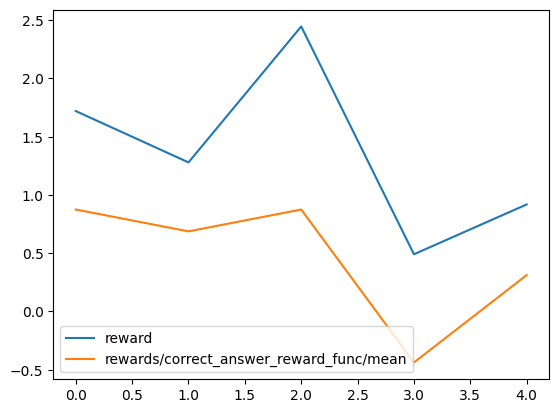

In [18]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

### Slower train (1+ hour)

If everything looks good, let's go for a longer training session!

In [19]:
# Now let's train for real! Let's do a longer training that will take an hour or more
# Note: If this run is successful, you can consider doing a longer train
# to see what happens, but that's beyond the scope of this project.
training_args = GRPOConfig(**COMMON_GRPO_TRAINING_PARAMS, max_steps=100)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 119,734,272 of 3,205,672,960 (3.74% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. l - 0 so far (no "l"s found yet)
3. i - 0 so far
4. s - 0 so far
5. n - 0 so far
6. t - 0 so far
7. e - 0 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,-0.008000,1.363690,2.123738,88.750000,39.000000,121.000000,0.000000,88.750000,39.000000,121.000000,0.003035,0.339286,0.288454,-1.000000,2.121320,0.149405,0.794057,1.000000,0.000000,0.875000,1.500000
2,0.030500,2.111632,1.860916,78.687500,57.000000,112.000000,0.000000,78.687500,57.000000,112.000000,0.000635,0.460938,0.055316,-0.343750,2.662823,0.119444,0.608760,1.000000,0.000000,0.875000,1.500000
3,-0.025100,1.822173,3.065728,81.937500,40.000000,102.000000,0.000000,81.937500,40.000000,102.000000,0.002089,0.427083,0.127173,-1.156250,2.357391,0.488839,0.658904,1.000000,0.000000,1.062500,1.436141
4,0.029500,0.819940,1.580729,79.375000,62.000000,93.000000,0.000000,79.375000,62.000000,93.000000,0.001543,0.468750,0.041667,0.000000,2.000000,-0.398810,0.570177,1.000000,0.000000,-0.250000,1.341641
5,-0.010800,2.419717,1.222475,81.312500,56.000000,108.000000,0.000000,81.312500,56.000000,108.000000,0.000587,0.441295,0.128061,0.125000,2.425558,-0.021577,0.562133,1.000000,0.000000,0.875000,1.500000
6,0.020300,1.624330,2.036326,85.562500,65.000000,104.000000,0.000000,85.562500,65.000000,104.000000,0.001754,0.414955,0.082285,-0.906250,1.772181,0.615625,0.560108,1.000000,0.000000,0.500000,1.549193
7,0.043700,0.411012,2.472310,72.750000,39.000000,102.000000,0.000000,72.750000,39.000000,102.000000,0.002565,0.368304,0.099076,-1.812500,1.691893,0.167708,0.739531,1.000000,0.000000,0.687500,1.537043
8,0.049200,0.027728,1.417213,91.937500,62.000000,122.000000,0.000000,91.937500,62.000000,122.000000,0.005405,0.425000,0.083168,-1.562500,1.965324,0.227728,0.645630,1.000000,0.000000,-0.062500,1.436141
9,0.027800,-0.079836,2.569301,90.937500,65.000000,117.000000,0.000000,90.937500,65.000000,117.000000,0.003208,0.415551,0.092014,-1.656250,2.165785,0.410863,0.650901,1.000000,0.000000,-0.250000,1.341641
10,0.043000,1.905208,1.525069,81.187500,62.000000,120.000000,0.000000,81.187500,62.000000,120.000000,0.002950,0.417411,0.087451,-0.250000,2.121320,0.237798,0.600953,1.000000,0.000000,0.500000,1.549193



--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word "sapphire"
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. h - 2 so far
6. a - 3 so far
7. p - 4 so far
8. y - 4 so far
9. e - 5 so far
</reasoning>
<answer>
5
</answer>
Extracted: 5
Correct: False!
    

--------------------
Question: How many of the letter "h" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of "h" in the word "absolve"
1. a - 0 so far
2. b - 0 so far
3. s - 0 so far
4. o - 0 so far
5. v - 0 so far
6. e - 0 so far
7. h - 0 so far
</reasoning>
<answer>
0
</answer>
Extracted: 0
Correct: True!
    

--------------------
Question: How many of the letter "g" are there in the word "mirage"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word "mirage"
1. m - 0 so far
2. i - 0 so far
3. r - 0 so far
4. a - 0 so far
5. g - 1 so far
6. e - 1 so f

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'clip_ratio/low_mean', 'clip_ratio/low_min', 'clip_ratio/high_mean', 'clip_ratio/high_max', 'clip_ratio/region_mean', 'epoch', 'step'])


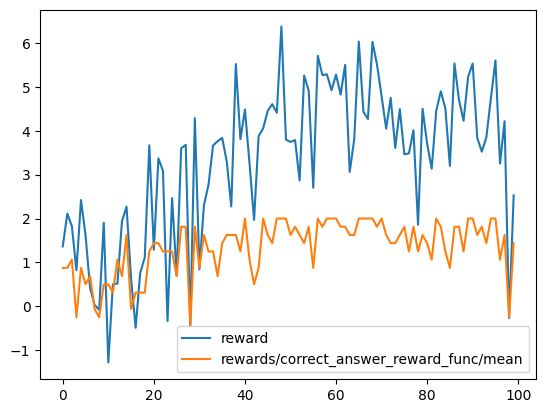

In [20]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# Do you see the rewards increasing? Does the model get the correct answer
# more frequently toward the end?
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

## View the results
Now let's try the model we just trained!

In [21]:
# Save the LoRA adapters
# No changes needed in this cell

# Save the LoRA model
from config import LORA_SAVE_DIR
model.save_lora(LORA_SAVE_DIR)

In [22]:
# Create a function to run both the original model and the updated model
# No changes needed in this cell


def compare_old_and_new_model(messages):
    from vllm import SamplingParams

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    sampling_params = SamplingParams(
        temperature=0.8,
        top_p=0.95,
        max_tokens=1024,
    )
    old = (
        model.fast_generate(
            text,
            sampling_params=sampling_params,
        )[0]
        .outputs[0]
        .text
    )

    new = (
        model.fast_generate(
            text,
            sampling_params=sampling_params,
            lora_request=model.load_lora("grpo_saved_lora"),
        )[0]
        .outputs[0]
        .text
    )

    print("===OLD===\n")
    print(old)

    print("\n\n===NEW===\n")
    print(new)


### Compare the old and new models on the letter-counting task

In [23]:
# Let's try spelling the first word from the dataset
# Load the first item from the dataset (index 0) and compare the old and new models
sample = ds[0]
compare_old_and_new_model(sample["prompt"])

Processed prompts: 100%|██████████| 1/1 [00:12<00:00, 12.42s/it, est. speed input: 8.46 toks/s, output: 5.40 toks/s]

===OLD===

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>


===NEW===

<reasoning>
Counting the number of "a" in the word "idea"
1. i - 0 so far
2. d - 0 so far
3. e - 0 so far
4. a - 1 so far
</reasoning>
<answer>
1
</answer>


Our model is better at spelling and counter letters in words! Depending on your reward functions, the size of your model, and the amount of steps trained, results may vary.

For about an hour of training time, your model may not be perfect (or maybe it is), but it's definitely moving in the right direction!

### Make sure the model did not forget basic facts

In [ ]:
# Ask both the old and new models a question the model is likely to know, e.g. a well-known capital city
compare_old_and_new_model([
    {"role": "system", "content": ""},
    {"role": "user", "content": "What is the capital of the Philippines?"},
])


Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.72s/it, est. speed input: 12.20 toks/s, output: 5.23 toks/s]

===OLD===

The capital of the Philippines is Manila.


===NEW===

The capital of the Philippines is Manila.


Great job! Congrats on completing the project! 🎉🤗